## Lecture 16 Exploratory Data Analysis with Pandas and Seaborn
* Understand the data types
* Detect any problems in the data file. 
* Detect any outliers or data that is questionable. 
* Understand the range/distribution of the variables
* Visualize the relationship between the variables

## Iris Flower

[UCI Data Repository](https://archive.ics.uci.edu/)

[Iris Flower Images](https://en.wikipedia.org/wiki/Iris_flower_data_set)

Small classic data set used frequently teaching of data science


In [182]:
import pandas as pd
import numpy as np 
from matplotlib import pyplot as plt 
import seaborn as sns 
iris = pd.read_csv('iris.csv')

### Pandas 
We make use of pandas to load the data.  . 
You might find this tutorial useful. 
[10 minutes to pandas](https://pandas.pydata.org/pandas-docs/stable/user_guide/10min.html)

The `.info()` method provides a basic overview of the contents of a data file.
 
    - object refers to categorical or text data 
    - int64 are integers
    - float64 are floating point numbers 

In [183]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [184]:
columns = list(iris.columns)
print(iris.keys()) #This is the same thing as the columns of the table 
print(columns)

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


**Two types of scientific questions:**
    
- Are there significant differences in the features (petal and sepal length and width) between flower types? - **statistics**
- Can I tell what flower it is from the features (petal and sepal length and width) - **statistical learning** or **machine learning**

You can examine the first few rows of the table in your jupyter notebook. 

In [185]:
iris.head(10)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


You can also take a look at a random sample 

In [186]:
iris.sample(10)

,sepal_length,sepal_width,petal_length,petal_width,species
60,5.0,2.0,3.5,1.0,versicolor
65,6.7,3.1,4.4,1.4,versicolor
33,5.5,4.2,1.4,0.2,setosa
55,5.7,2.8,4.5,1.3,versicolor
27,5.2,3.5,1.5,0.2,setosa
76,6.8,2.8,4.8,1.4,versicolor
30,4.8,3.1,1.6,0.2,setosa
125,7.2,3.2,6.0,1.8,virginica
1,4.9,3.0,1.4,0.2,setosa
19,5.1,3.8,1.5,0.3,setosa


### Using numpy with pandas Series 
Pandas Series can be operated on using numpy methods with two different syntax 

In [187]:
#Here I pass the data to numpy functions 
types = np.unique(iris['species'])
print(types)
petal_length = np.mean(iris['petal_length'])
print(petal_length)

['setosa' 'versicolor' 'virginica']
3.7580000000000005


But you can also use this syntax, where you use numpy functions as methods on the Series. 

In [188]:
#Here I invoke numpy functions as methods 
types = iris['species'].unique()
print(types)
petal_length = iris['petal_length'].mean()
print(petal_length)

['setosa' 'versicolor' 'virginica']
3.7580000000000005


### Descriptive Statistics
You can quickly grab descriptive statistics using `describe`

`describe` will ignore all the categorical variables, and only report on numeric variables. 

In [189]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


For categorical variables, `.value_counts()` can be useful to summarize the data 

In [190]:
# How many samples do I have of each species
iris["species"].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

The `groupby()` method can be used to use one variable to group the data before making a calculation. 

As an example, lets group the data by species before calculating the means of petal_length

In [191]:
petal_means = iris['petal_length'].groupby(iris['species']).mean()
print(petal_means)

species
setosa        1.462
versicolor    4.260
virginica     5.552
Name: petal_length, dtype: float64


Making a new dataframe and adding to an existing data frame 

- Making a new dataframe is similar to making a new dictionary and the syntax follows very closely.
- The most important property of a **DataFrame** is its **columns**   
- A general label for this type of indexing is "keys" which is what we called it in a dictionary 
* **keys** are a label assigned to each column of the csv or xls file. Pandas also calls it **columns**
*  DataFrames are similar to a dictionary, but are more restricted. 
* In a dictionary, you can combine together various types of information of varying size  and assign each one a key. 
* In a data frame, each key corresponds to the column of a table, and each column is a list or array **OF EXACTLY THE SAME LENGTH**

Since I am going to mess up the iris dataframe, I am going to work with a copy instead.  
Its a good rule of thumb to use the copy methods for dataframes (and numpy arrays) instead of = when you want to make a copy. Why? 

In [192]:

df = iris.copy()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


Adding a column to a dataframe 

Lets assume I want to add two columns to the dataframe df which are measures of area, (length x width)



In [193]:
petal_area = df['petal_length']*df['petal_width']
sepal_area = df['sepal_length']*df['sepal_width']


I can just add to the dataframe, by adding a column

In [194]:
df['p_area'] = petal_area
df['s_area'] = sepal_area
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
 5   p_area        150 non-null    float64
 6   s_area        150 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.3+ KB


Suppose I want a clean data frame that just has the area variables and the species. Lets make a new data frame called area 

In [195]:
area = pd.DataFrame({'species':df['species'], 'petal_area':petal_area, 'sepal_area':sepal_area})
area.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   species     150 non-null    object 
 1   petal_area  150 non-null    float64
 2   sepal_area  150 non-null    float64
dtypes: float64(2), object(1)
memory usage: 3.6+ KB


### Making plots using Seaborn

The seaborn libraries work directly on pandas dataframes for visualization. 

`seaborn` organizes calls to `matplotlib` into a single function. 

The strength of `seaborn` over `matplotlib` is that they have figured out how to combine many operations that we would normally do individually into a single program call. 

Notice, that I still make use of `matplotlib` to set up my figure, etc. Under the hood, `seaborn` is `matplotlib` 

Histograms provide useful ways to examine the distribution of values in your data.  

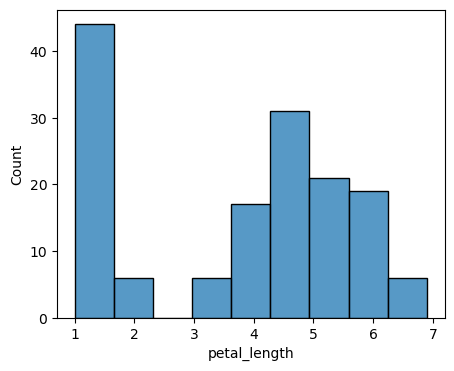

In [196]:
plt.figure(figsize=(5,4))
sns.histplot(iris, x='petal_length')
plt.show()

What would be really nice is if we could visualize the 3 different species in different colors 

In all seaborn functions, you can assign the argument **hue** to a categorical variable, and display it with different colors. 

multiple = "dodge" is useful.  if we make the plot without it kind of sucks.  

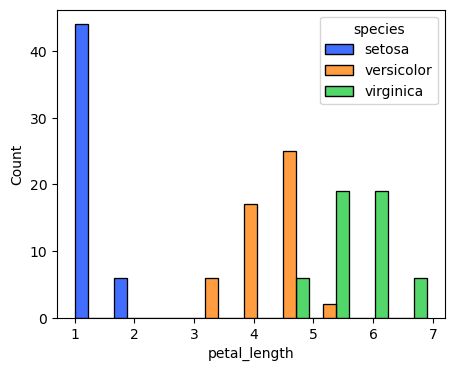

In [210]:
plt.figure(figsize=(5,4))
sns.histplot(iris, x='petal_length', hue = 'species',multiple = "dodge", palette = "bright")
plt.show()

When you make any type of bar plot, you should always know exactly where the bars are being drawn

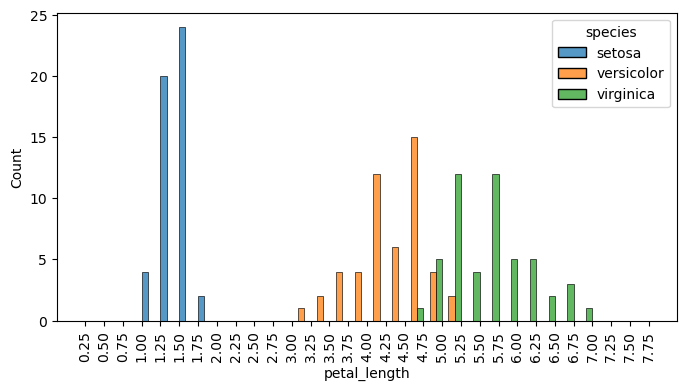

In [198]:
plt.figure(figsize=(8,4))
sns.histplot(iris, x='petal_length', hue = 'species', multiple='dodge', bins= np.arange(0.25,8,0.25))
plt.xticks(np.arange(0.25,8,0.25),rotation = 90)
plt.show()

 The above graph gives the counts of each observation.  What if we 

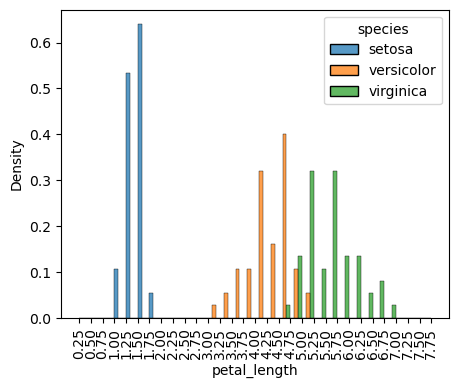

In [199]:
plt.figure(figsize=(5,4))
sns.histplot(iris, x='petal_length', hue = 'species', multiple='dodge', bins= np.arange(0.25,8,0.25), stat = "density")
plt.xticks(np.arange(0.25,8,0.25),rotation = 90)
plt.show()

A useful option in histplots is to make a smooth continuous line through your bars.  This only makes sense if your x variable is truly continuous. 

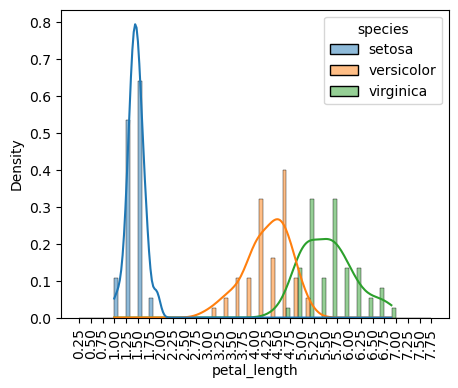

In [200]:
plt.figure(figsize=(5,4))
sns.histplot(iris, x='petal_length', hue = 'species', multiple='dodge', bins= np.arange(0.25,8,0.25), stat = "density", kde = True)
plt.xticks(np.arange(0.25,8,0.25),rotation = 90)
plt.show()

I like that plot, lets make all 4 variables, using subplot

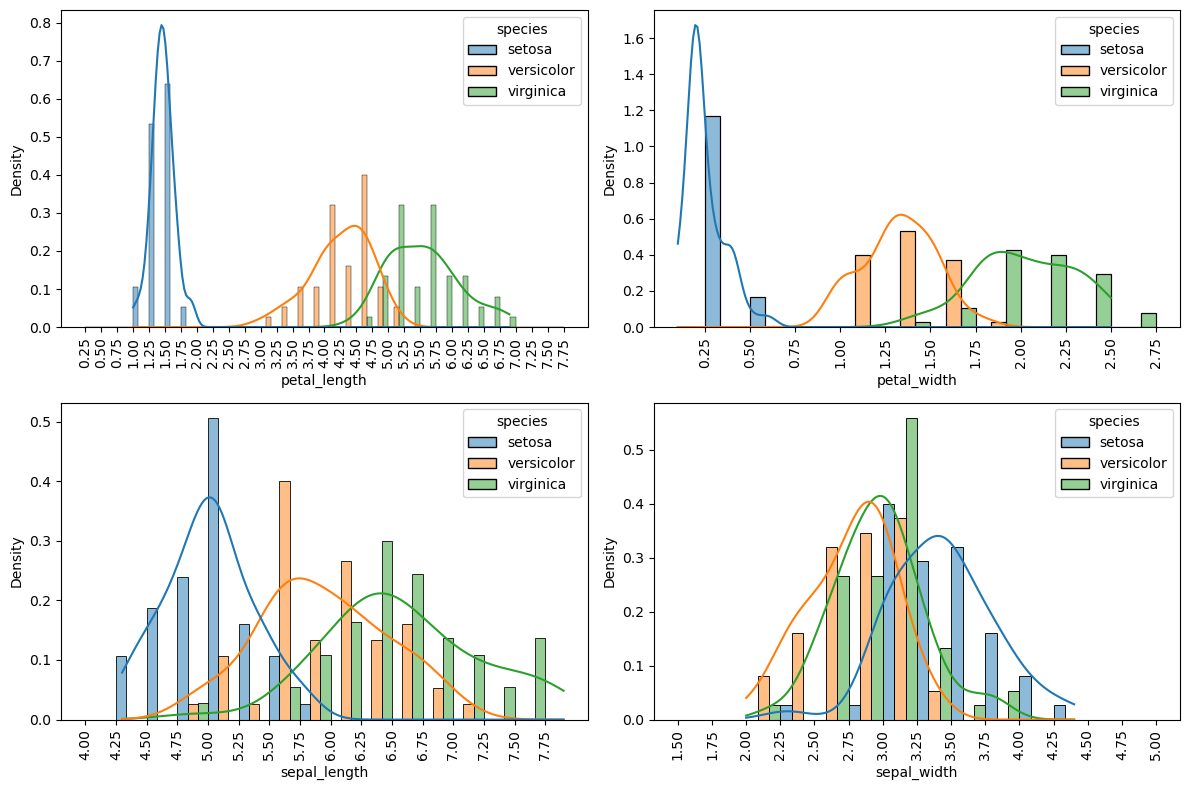

In [213]:
plt.figure(figsize = (12,8))
plt.subplot(2,2,1)
sns.histplot(iris, x='petal_length', hue = 'species', multiple='dodge', bins= np.arange(0.25,8,0.25), stat = "density", kde = True)
plt.xticks(np.arange(0.25,8,0.25),rotation = 90)

plt.subplot(2,2,2)
sns.histplot(iris, x='petal_width', hue = 'species', multiple='dodge', bins= np.arange(0.25,3,0.25), stat = "density", kde = True)
plt.xticks(np.arange(0.25,3,0.25),rotation = 90)

plt.subplot(2,2,3)
sns.histplot(iris, x='sepal_length', hue = 'species', multiple='dodge', bins= np.arange(4,8,0.25), stat = "density", kde = True)
plt.xticks(np.arange(4,8,0.25),rotation = 90)

plt.subplot(2,2,4)
sns.histplot(iris, x='sepal_width', hue = 'species', multiple='dodge', bins= np.arange(1.5,5.25,0.25), stat = "density", kde = True)
plt.xticks(np.arange(1.5,5.25,0.25),rotation = 90)

plt.tight_layout()
plt.show()



Thats truly terrible.  To make this graph, we need to know the range of values of each variable.  

A boxplot can be extremely useful in expressing the range of the data and detecting data that may have outliers. 

In a box plot: 

- the box shows the median (the line) and the 25% (bottom of box - Q1) and 75% (top of box - Q3) boundaries of the data 

- the whiskers show the full range of the data not including the outliers. 

- outliers are shown as dots.  outliers are points 
    - below Q1 - 1.5*(Q3-Q1)
    - above Q3 + 1.5*(Q3-Q1)

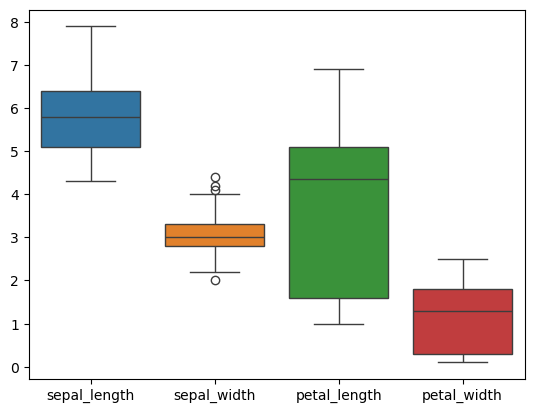

In [202]:
sns.boxplot(data=iris)
plt.show()

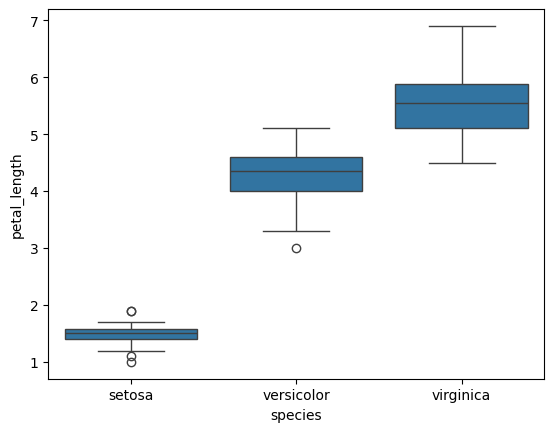

In [203]:
sns.boxplot(data=iris, x= 'species',y='petal_length')
plt.show()

There are other ways to visualize the distribution of the data, here are two common ones, applied to sepal_width
The first is the violin plot.  

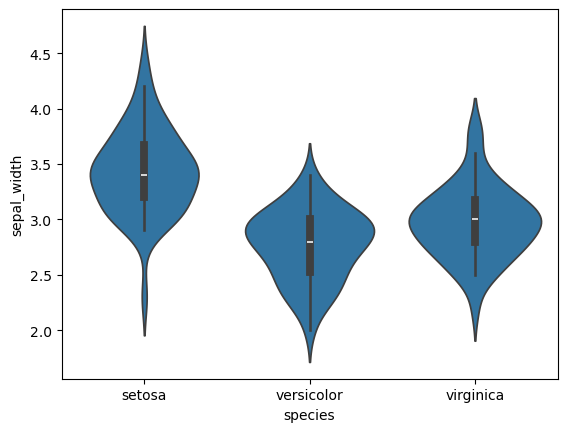

In [204]:
sns.violinplot( data=iris, y = 'sepal_width', x = 'species')
plt.show()

I prefer the swarm plot 

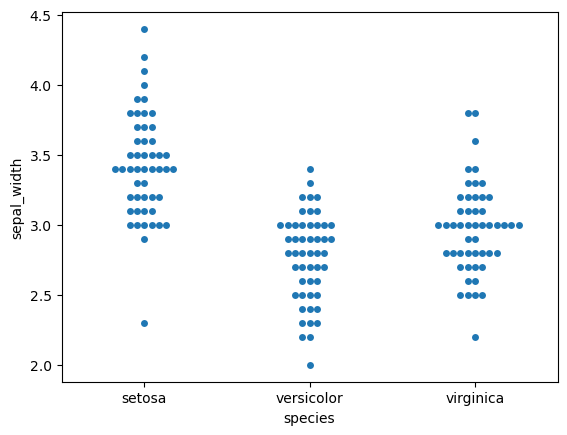

In [205]:

plt.figure() 
sns.swarmplot(y='sepal_width', x='species', data=iris)
plt.show()

Our data is multivariate- i.e., we observed more that one variable for each observation - so we often want to look at the joint distribution of the data, with a jointplot 

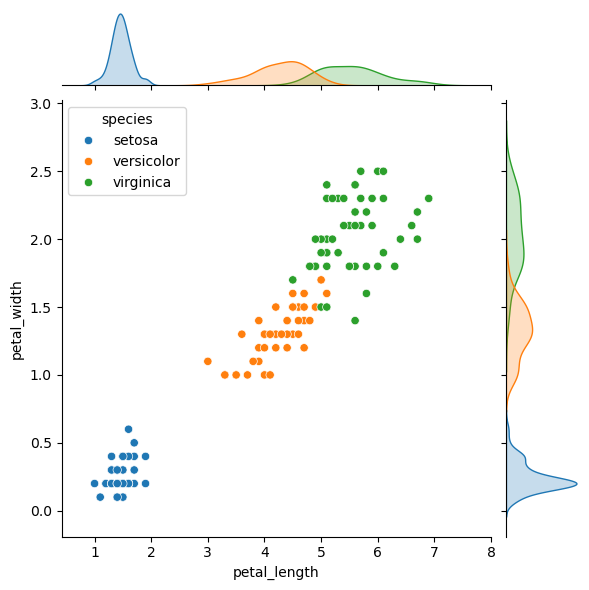

In [206]:
sns.jointplot(x='petal_length', y='petal_width', hue = "species",data=iris)
plt.show()

If you just want to look at it all, `pairplot` provides an overall view of all of the data. 

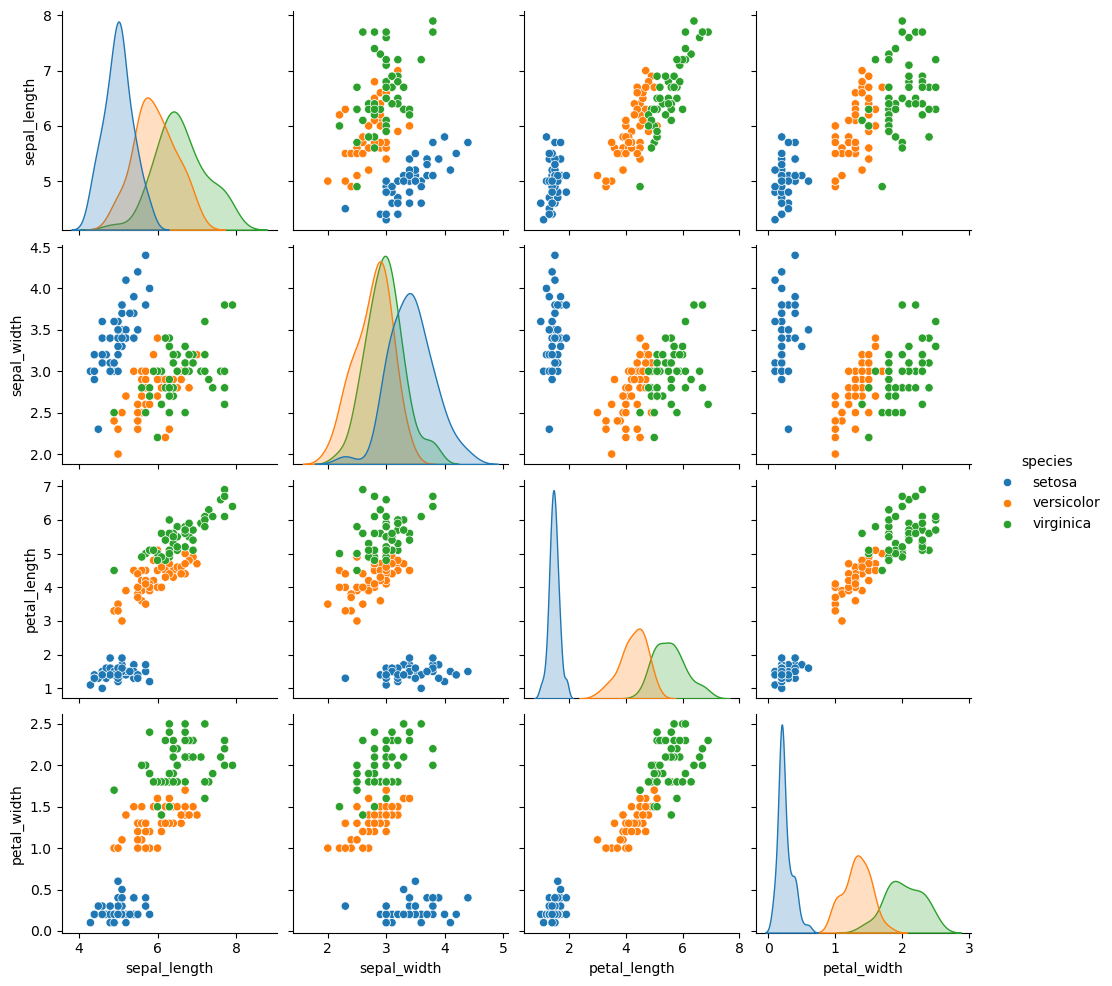

In [207]:

sns.pairplot(iris, hue="species");
plt.show()


**Pandas**
- pandas.read_csv()
- pandas.concat()
- pandas.get_dummies()
- DataFrame.info()
- DataFrame.head()
- DataFrame.sample()
- DataFrame.describe()
- DataFrame.unique()
- DataFrame.str
- DataFrame.groupby()
- DataFrame.sort_values()
- DataFrameGroupBy.size()


**seaborn**
- seaborn.boxplot()
- seaborn.histplot()
- seaborn.barplot()
- seaborn.countplot()
- seaborn.scatterplot()
- seaborn.violinplot()
- seaborn.lineplot() 
- seaborn.pairplot()
- seaborn.heatmap()